In [2]:
!pip install dagshub mlflow -q

import dagshub
import mlflow
import pandas as pd
import numpy as np
from kaggle_secrets import UserSecretsClient

# 1. Connect to DagsHub
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("DAGSHUB_TOKEN")

dagshub.init(repo_owner='kvizhmena11', repo_name='ML-assignment2-IEEE-Fraud-Detection', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow")
mlflow.set_experiment("XGBoost_Training")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 97.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=4d94324d-aa6f-4a1d-88b1-c76125e2329f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=17de6d8b621f67ede4bf1d04ac1a281ef5b5598f09952e301c3652b2ec467b4d




Accessing as kvizhmena11

Initialized MLflow to track repo "kvizhmena11/ML-assignment2-IEEE-Fraud-Detection"

Repository kvizhmena11/ML-assignment2-IEEE-Fraud-Detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/f4bb435ff8ca45d5b69386e3bf1bfd6d', creation_time=1778144493120, experiment_id='0', last_update_time=1778144493120, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

# 🧹 Cleaning

In [6]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtype
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [7]:
import os
mlflow.end_run()

base_path = '/kaggle/input/competitions/ieee-fraud-detection/'

with mlflow.start_run(run_name="XGBoost_Cleaning"):
    train_transaction = pd.read_csv(os.path.join(base_path, 'train_transaction.csv'))
    train_identity = pd.read_csv(os.path.join(base_path, 'train_identity.csv'))
    
    train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
    del train_transaction, train_identity
    
    nan_count = train.isna().sum().sum()
    mlflow.log_metric("initial_nan_count", nan_count)
    
    train = reduce_mem_usage(train)
    
    mlflow.log_param("total_rows", len(train))
    mlflow.log_param("total_columns", len(train.columns))
    print(f"✅ Dataset shape: {train.shape}")

/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2256633342.py:19: RuntimeWarning: overfl

Mem. usage decreased to 645.97 Mb (67.0% reduction)
✅ Dataset shape: (590540, 434)
🏃 View run XGBoost_Cleaning at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/330aa67ca5e447d0bb4423db99e14e6d
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


# ⚙️ Feature Engineering

In [12]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering", nested=True):
    
    # --- 1. Email Domain Grouping ---
    # Many emails are the same (gmail vs gmail.com). Let's group them.
    emails = {'gmail': 'google', 'att.net': 'at&t', 'twc.com': 'spectrum', 
              'sc.rr.com': 'spectrum', 'nycap.rr.com': 'spectrum', 'outlook.com': 'microsoft', 
              'msn.com': 'microsoft', 'live.com.mx': 'microsoft', 'hotmail.es': 'microsoft', 
              'hotmail.com': 'microsoft', 'hotmail.de': 'microsoft', 'hotmail.co.uk': 'microsoft', 
              'live.com': 'microsoft', 'outlook.es': 'microsoft', 'live.fr': 'microsoft', 
              'icloud.com': 'apple', 'mac.com': 'apple', 'me.com': 'apple', 
              'prodigy.net.mx': 'at&t', 'sbcglobal.net': 'at&t', 'bellsouth.net': 'at&t'}
    
    for c in ['P_emaildomain', 'R_emaildomain']:
        train[c + '_bin'] = train[c].map(emails)
        train[c + '_suffix'] = train[c].map(lambda x: str(x).split('.')[-1])
    
    # --- 2. Time Engineering ---
    # TransactionDT is in seconds. Let's make it useful.
    train['Trans_hour'] = (train['TransactionDT'] // 3600) % 24
    train['Trans_day_of_week'] = (train['TransactionDT'] // (3600 * 24)) % 7
    
    # --- 3. Categorical Encoding (Label Encoding) ---
    from sklearn.preprocessing import LabelEncoder
    
    # Identify categorical columns
    cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 
                'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 
                'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 
                'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'P_emaildomain_bin',
                'P_emaildomain_suffix', 'R_emaildomain_bin', 'R_emaildomain_suffix']
    
    for col in cat_cols:
        if col in train.columns:
            le = LabelEncoder()
            # Fill NaN with a string so LabelEncoder doesn't crash
            train[col] = le.fit_transform(train[col].astype(str))
            
    mlflow.log_param("engineered_features_count", 6) # Hour, Day, 4 Email features
    print(f"Feature Engineering complete. New shape: {train.shape}")

/tmp/ipykernel_57/235055394.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[c + '_bin'] = train[c].map(emails)
/tmp/ipykernel_57/235055394.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[c + '_suffix'] = train[c].map(lambda x: str(x).split('.')[-1])
/tmp/ipykernel_57/235055394.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Feature Engineering complete. New shape: (590540, 440)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/3f17eda181df4359821ec0f6974cffbe
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


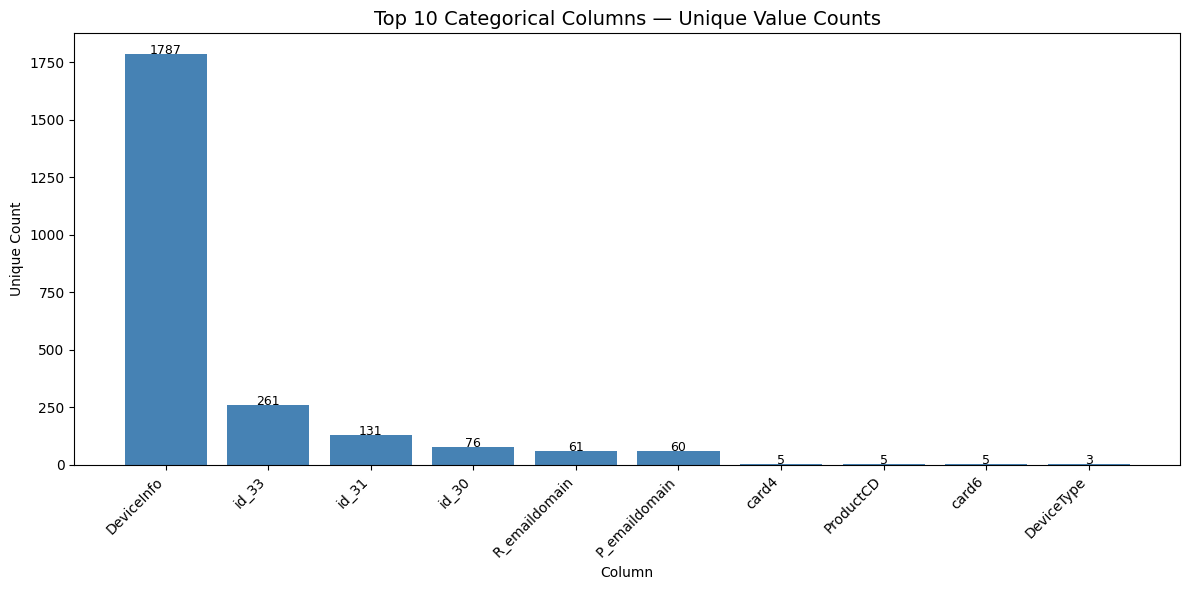

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/c1f16dd59763458fbd4e184a27966f38
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [13]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering", nested=True):
    mlflow.log_param("engineered_features_count", 6)

    import matplotlib.pyplot as plt
    raw_cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
                    'DeviceType', 'DeviceInfo', 'id_30', 'id_31', 'id_33']
    existing = [c for c in raw_cat_cols if c in train.columns]
    unique_counts = train[existing].nunique().sort_values(ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    bars = plt.bar(unique_counts.index, unique_counts.values, color='steelblue')
    for bar, val in zip(bars, unique_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=9)
    plt.title('Top 10 Categorical Columns — Unique Value Counts', fontsize=14)
    plt.xlabel('Column')
    plt.ylabel('Unique Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('xgb_cat_cardinality.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('xgb_cat_cardinality.png')
    plt.show()

# 🎯 Feature Selection

In [14]:
with mlflow.start_run(run_name="XGBoost_Feature_Selection", nested=True):
    print("De-fragmenting DataFrame...")
    # This removes the fragmentation warning and optimizes memory
    train = train.copy()
    
    print("Starting Feature Selection...")
    # 1. Identify columns with more than 90% missing values
    threshold = 0.90
    null_cols = [c for c in train.columns if train[c].isnull().sum() / len(train) > threshold]
    
    # 2. Identify columns with only 1 unique value (they provide no info)
    one_value_cols = [c for c in train.columns if train[c].nunique() <= 1]
    
    # Combine lists and drop
    cols_to_drop = list(set(null_cols + one_value_cols))
    if 'isFraud' in cols_to_drop: cols_to_drop.remove('isFraud') # Don't drop the target!
    
    train.drop(cols_to_drop, axis=1, inplace=True)
    
    # Log the selection process
    mlflow.log_param("cols_dropped_count", len(cols_to_drop))
    mlflow.log_param("final_feature_count", train.shape[1])
    
    print(f"✅ Dropped {len(cols_to_drop)} columns. Final shape: {train.shape}")

De-fragmenting DataFrame...
Starting Feature Selection...
✅ Dropped 0 columns. Final shape: (590540, 440)
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/1edfaa346bf84802ace874fa3f7ec288
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


# 🧹 Cleaning

In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1)
y = train['isFraud']

# Time-based split (No shuffling to avoid "look-ahead" bias)
# We take the first 80% for training and last 20% for validation
split_idx = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} rows, Validating on {len(X_val)} rows.")

Training on 472432 rows, Validating on 118108 rows.


In [15]:
!pip install dagshub mlflow -q

# 🚀 Training

In [15]:
import os
import pandas as pd
import mlflow
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# --- 1. Categorical Preprocessing ---
# Identifying columns with string/object data types
cat_cols = X_train.select_dtypes(include=['object']).columns

# Converting them to the 'category' dtype which XGBoost's hist method loves
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

# --- 2. Model Configuration ---
params = {
    'n_estimators': 500,
    'max_depth': 9,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'tree_method': 'hist',      # Required for categorical support
    'random_state': 42,
    'enable_categorical': True  # Tells XGBoost to handle 'category' dtypes automatically
}

# --- 3. Training & MLflow Tracking ---
# Note: nested=True is used if you are calling this inside another mlflow run
with mlflow.start_run(run_name="XGBoost_Model_Training", nested=True):
    
    # Log hyperparameters
    mlflow.log_params(params)
    
    # Initialize and Train
    print("🚀 Training model...")
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Predict probabilities (specifically for the positive class [:, 1])
    print("📊 Calculating predictions...")
    train_preds = model.predict_proba(X_train)[:, 1]
    val_preds = model.predict_proba(X_val)[:, 1]
    
    # Calculate AUC Scores
    train_auc = roc_auc_score(y_train, train_preds)
    val_auc = roc_auc_score(y_val, val_preds)
    
    # Log metrics to MLflow
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    
    # Final Output
    print("-" * 30)
    print(f"✅ Training Complete!")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Val AUC:   {val_auc:.4f}")
    print("-" * 30)

/tmp/ipykernel_57/2200224468.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/tmp/ipykernel_57/2200224468.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype('category')
/tmp/ipykernel_57/2200224468.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

🚀 Training model...
📊 Calculating predictions...
------------------------------
✅ Training Complete!
Train AUC: 0.9902
Val AUC:   0.9168
------------------------------
🏃 View run XGBoost_Model_Training at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/5812ddd83c2542cbb10dea6310d8a800
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


# 🧹 Cleaning

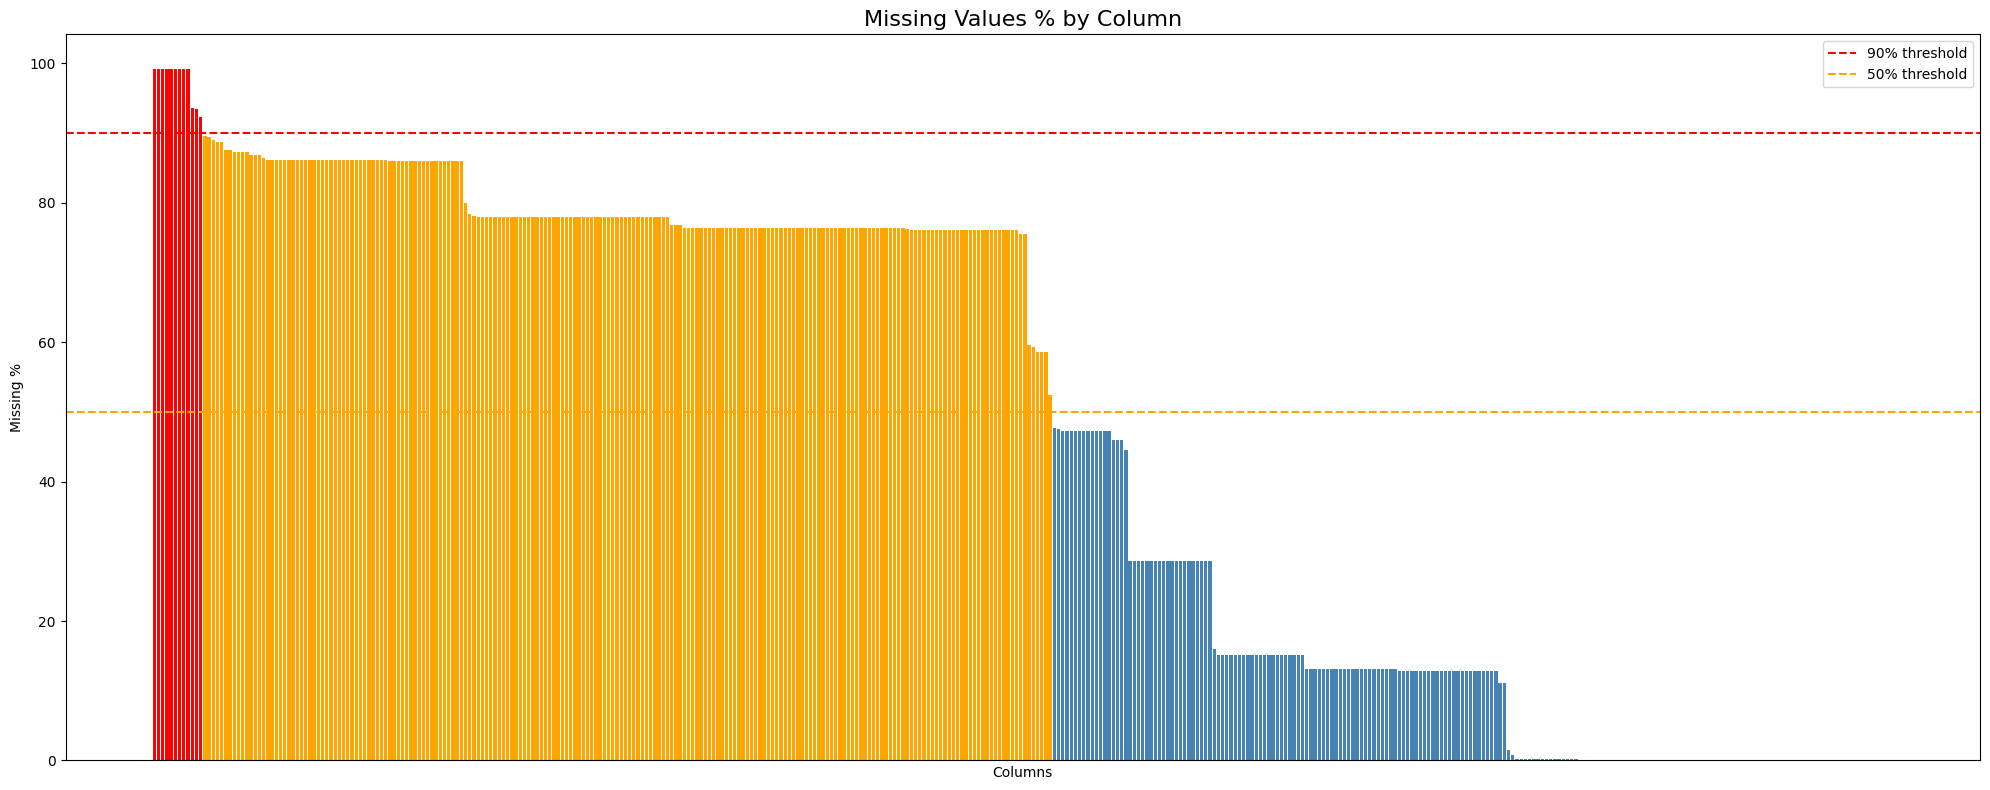

Red (90%+): 12
Orange (50-90%): 202
Blue (0-50%): 200


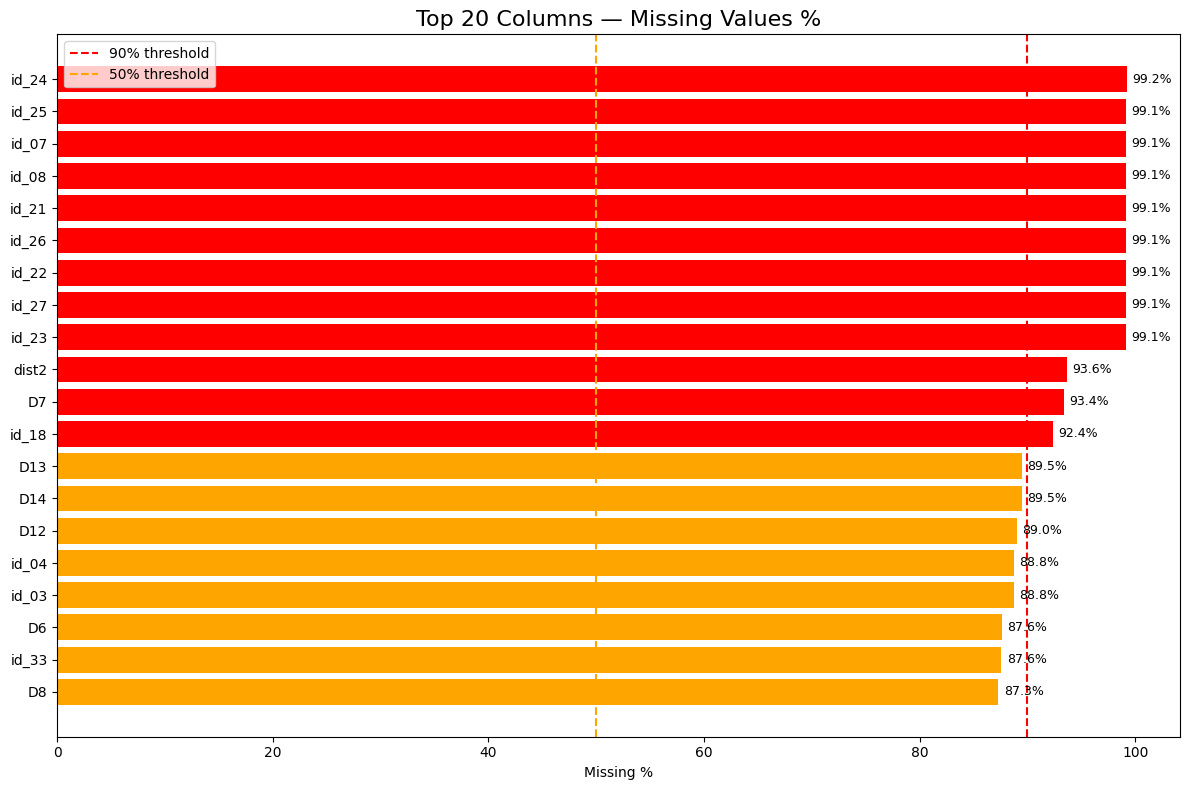

🏃 View run XGBoost_Cleaning at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/91dc7c1508404357bc05aaa4028fe46c
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [9]:
with mlflow.start_run(run_name="XGBoost_Cleaning", nested=True):
    mlflow.log_param("nan_fill_strategy", "numeric=-999, categorical=label_encoded_as_string")
    mlflow.log_param("rows_after_cleaning", len(train))
    
    import matplotlib.pyplot as plt
    
    # ✅ Calculate BEFORE filling NaNs
    missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    
    # Chart 1 — Overview
    plt.figure(figsize=(20, 8))
    colors = ['red' if x > 90 else 'orange' if x > 50 else 'steelblue' for x in missing.values]
    plt.bar(range(len(missing)), missing.values, color=colors)
    plt.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
    plt.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='50% threshold')
    plt.title('Missing Values % by Column', fontsize=16)
    plt.xlabel('Columns')
    plt.ylabel('Missing %')
    plt.legend()
    plt.xticks([])
    plt.tight_layout()
    plt.savefig('xgb_missing_overview.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('xgb_missing_overview.png')
    plt.show()
    print(f"Red (90%+): {(missing > 90).sum()}")
    print(f"Orange (50-90%): {((missing > 50) & (missing <= 90)).sum()}")
    print(f"Blue (0-50%): {(missing <= 50).sum()}")

    # Chart 2 — Top 20
    plt.figure(figsize=(12, 8))
    top20 = missing.head(20)
    colors20 = ['red' if x > 90 else 'orange' if x > 50 else 'steelblue' for x in top20.values]
    bars = plt.barh(range(len(top20)), top20.values, color=colors20)
    plt.axvline(x=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
    plt.axvline(x=50, color='orange', linestyle='--', linewidth=1.5, label='50% threshold')
    plt.yticks(range(len(top20)), top20.index)
    for i, (val, bar) in enumerate(zip(top20.values, bars)):
        plt.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
    plt.title('Top 20 Columns — Missing Values %', fontsize=16)
    plt.xlabel('Missing %')
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.savefig('xgb_missing_top20.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('xgb_missing_top20.png')
    plt.show()

    # ✅ NOW fill NaNs — AFTER plotting
    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        if col not in ['isFraud', 'TransactionID']:
            train[col] = train[col].fillna(-999)

In [11]:
with mlflow.start_run(run_name="XGBoost_Cleaning", nested=True):
  
    fraud_rate = train['isFraud'].mean()
    mlflow.log_metric("fraud_rate_pct", fraud_rate * 100)
    mlflow.log_metric("class_imbalance_ratio", (1 - fraud_rate) / fraud_rate)
    

    identity_nan_pct = train[[c for c in train.columns if 'id_' in c]].isnull().mean().mean()
    v_nan_pct = train[[c for c in train.columns if c.startswith('V')]].isnull().mean().mean()
    mlflow.log_metric("identity_cols_avg_nan_pct", identity_nan_pct)
    mlflow.log_metric("V_cols_avg_nan_pct", v_nan_pct)
    
    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        if col not in ['isFraud', 'TransactionID']:
            train[col] = train[col].fillna(-999)
    
    mlflow.log_param("nan_fill_strategy", "numeric=-999, categorical=label_encoded_as_string")
    mlflow.log_param("rows_after_cleaning", len(train))

🏃 View run XGBoost_Cleaning at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/56867845c43e43ecb7dd9a0018d20030
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


# ⚙️ Feature Engineering

In [16]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering", nested=True):
    
    for col in ['card1', 'card2', 'card3', 'card5']:
        if col in train.columns:
            freq = train[col].astype(np.float32).value_counts(normalize=True)
            train[f'{col}_freq'] = train[col].astype(np.float32).map(freq)
    
    train['TransactionAmt_log'] = np.log1p(train['TransactionAmt'])
    train['TransactionAmt_decimal'] = ((train['TransactionAmt'].astype(np.float32) - train['TransactionAmt'].astype(int)) * 1000).astype(int)
    
    train['card1_TransactionAmt_mean'] = train.groupby(train['card1'].astype(np.float32))['TransactionAmt'].transform('mean')
    train['card1_TransactionAmt_std'] = train.groupby(train['card1'].astype(np.float32))['TransactionAmt'].transform('std')
    train['amt_vs_card_mean'] = train['TransactionAmt'] / (train['card1_TransactionAmt_mean'] + 1)
    
    train['TransactionAmt_zscore'] = (
        (train['TransactionAmt'] - train['card1_TransactionAmt_mean']) / 
        (train['card1_TransactionAmt_std'] + 1)
    )
    
    if 'addr1' in train.columns and 'addr2' in train.columns:
        train['addr_match'] = (train['addr1'] == train['addr2']).astype(int)
    
    train = train.copy()
    
    mlflow.log_param("total_engineered_features", 8)
    mlflow.log_param("feature_types", "freq_encoding, log_transform, group_aggregations, interactions")
    print(f"Shape after FE: {train.shape}")

Shape after FE: (590540, 451)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/5459bcef753e47878f12fcb097f12dae
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


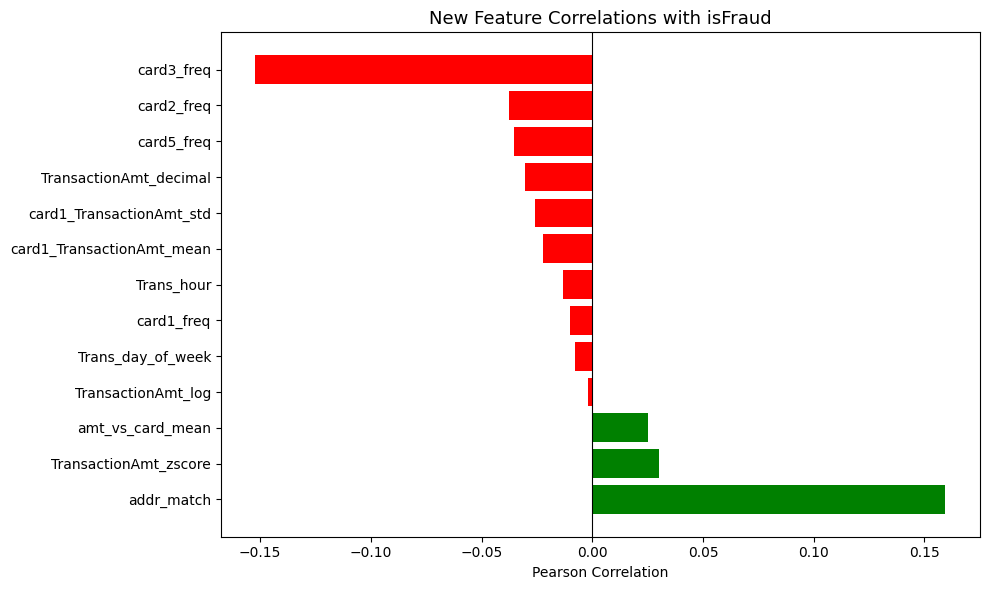

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/e2ccc7c6997e4316b1c11cec8924ce23
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [17]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering", nested=True):
    mlflow.log_param("total_engineered_features", 8)

    import matplotlib.pyplot as plt
    new_fe_cols = [c for c in train.columns if any(tag in c for tag in
        ['_freq', '_log', '_decimal', '_mean', '_std', '_zscore',
         'amt_vs', 'Trans_hour', 'Trans_day', 'addr_match'])]
    new_fe_cols = [c for c in new_fe_cols if c in train.columns]
    tmp = train[new_fe_cols + ['isFraud']].copy()
    corrs = tmp.corr()['isFraud'].drop('isFraud').sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    bar_colors = ['green' if x > 0 else 'red' for x in corrs.values]
    plt.barh(corrs.index, corrs.values, color=bar_colors)
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title('New Feature Correlations with isFraud', fontsize=13)
    plt.xlabel('Pearson Correlation')
    plt.tight_layout()
    plt.savefig('xgb_fe_correlations.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('xgb_fe_correlations.png')
    plt.show()

# 🎯 Feature Selection

In [18]:
with mlflow.start_run(run_name="XGBoost_Feature_Selection", nested=True):
    
    threshold = 0.90
    null_cols = [c for c in train.columns if train[c].isnull().sum() / len(train) > threshold]
    one_value_cols = [c for c in train.columns if train[c].nunique() <= 1]
    cols_to_drop = list(set(null_cols + one_value_cols))
    for c in ['isFraud', 'TransactionID', 'TransactionDT']:
        if c in cols_to_drop:
            cols_to_drop.remove(c)
    train.drop(cols_to_drop, axis=1, inplace=True)
    mlflow.log_param("cols_dropped_null_or_constant", len(cols_to_drop))

    from xgboost import XGBClassifier
    
    X_fs = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
    y_fs = train['isFraud']
    
    sample_idx = X_fs.sample(frac=0.1, random_state=42).index
    X_sample = X_fs.loc[sample_idx]
    y_sample = y_fs.loc[sample_idx]
    
    quick_model = XGBClassifier(n_estimators=100, max_depth=6, tree_method='hist', random_state=42)
    quick_model.fit(X_sample, y_sample)
    
    importances = pd.Series(quick_model.feature_importances_, index=X_fs.columns)
    selected_features = importances[importances > 0.001].index.tolist()
    removed_low_importance = len(X_fs.columns) - len(selected_features)
    
    mlflow.log_param("selection_method", "xgboost_importance_on_10pct_sample")
    mlflow.log_param("importance_threshold", 0.001)
    mlflow.log_param("features_removed_low_importance", removed_low_importance)
    mlflow.log_param("final_selected_features", len(selected_features))
    
    print(f"Selected {len(selected_features)} features out of {len(X_fs.columns)}")

Selected 167 features out of 448
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/94b3f1e0ffd7498392f6143b316e84b2
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


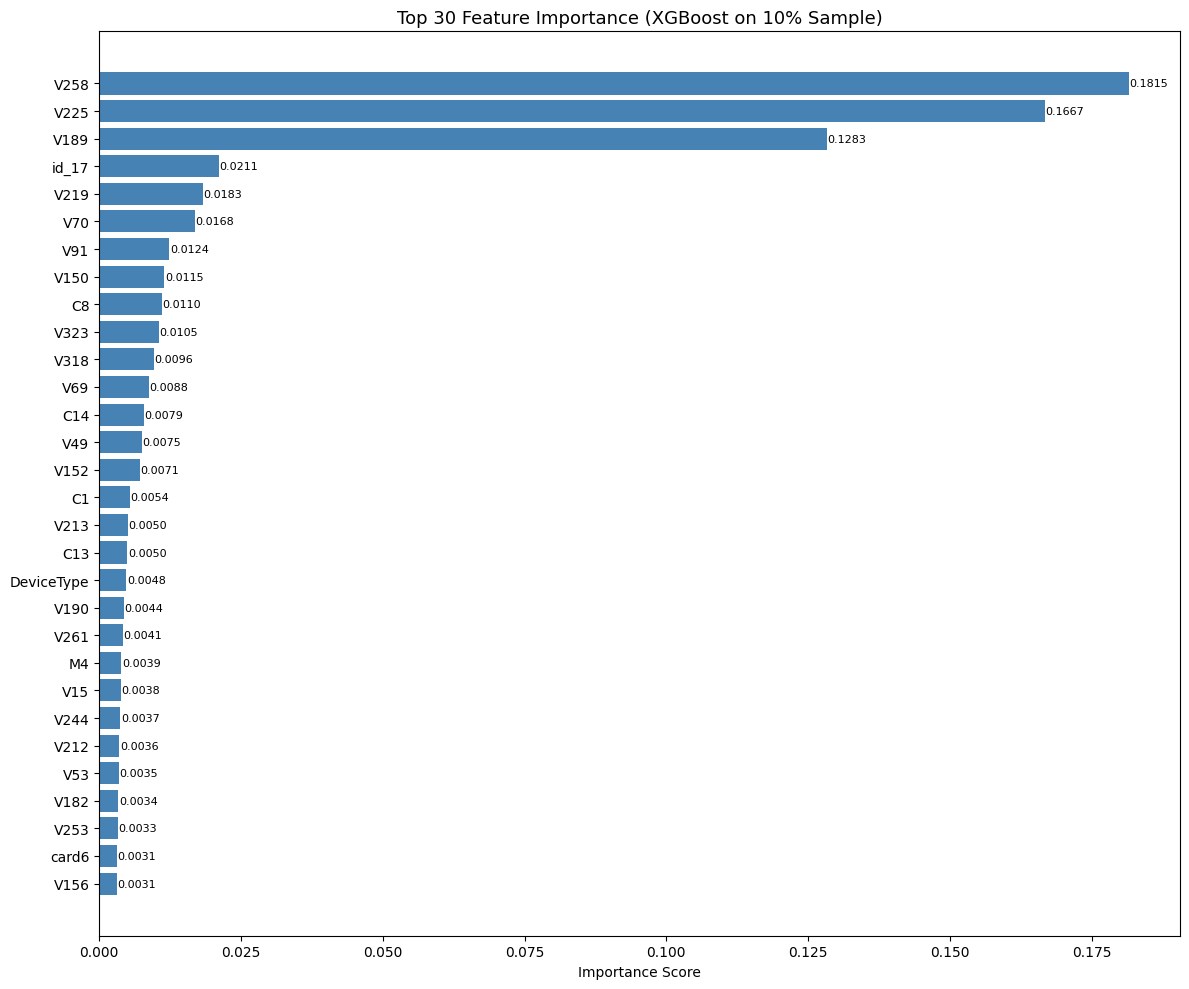

In [19]:
quick_model.fit(X_sample, y_sample)

import matplotlib.pyplot as plt
importances = pd.Series(quick_model.feature_importances_, index=X_fs.columns)
top30 = importances.sort_values(ascending=False).head(30)
plt.figure(figsize=(12, 10))
bars = plt.barh(range(len(top30)), top30.values, color='steelblue')
plt.yticks(range(len(top30)), top30.index)
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Importance (XGBoost on 10% Sample)', fontsize=13)
plt.xlabel('Importance Score')
for i, (val, bar) in enumerate(zip(top30.values, bars)):
    plt.text(val + 0.0001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
mlflow.log_artifact('xgb_feature_importance.png')
plt.show()

selected_features = importances[importances > 0.001].index.tolist()

# 🎯 Feature Selection

In [20]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X = train[selected_features]
y = train['isFraud']
split_idx = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 472432 | Val: 118108


# 🚀 Training

In [21]:
with mlflow.start_run(run_name="XGBoost_Underfit", nested=True):
    params = {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.3, 
              'tree_method': 'hist', 'random_state': 42}
    mlflow.log_params(params)
    mlflow.log_param("experiment_purpose", "underfitting_demonstration")
    
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, m.predict_proba(X_train)[:,1])
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("overfit_gap", train_auc - val_auc)
    print(f"[UNDERFIT] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc-val_auc:.4f}")

[UNDERFIT] Train: 0.8816 | Val: 0.8643 | Gap: 0.0173
🏃 View run XGBoost_Underfit at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/af5ce5adaeb74ee7bcb45d037e67846b
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [22]:
with mlflow.start_run(run_name="XGBoost_Overfit", nested=True):
    params = {'n_estimators': 1000, 'max_depth': 15, 'learning_rate': 0.3,
              'subsample': 1.0, 'colsample_bytree': 1.0,
              'tree_method': 'hist', 'random_state': 42}
    mlflow.log_params(params)
    mlflow.log_param("experiment_purpose", "overfitting_demonstration")
    
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, m.predict_proba(X_train)[:,1])
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("overfit_gap", train_auc - val_auc)
    print(f"[OVERFIT] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc-val_auc:.4f}")

[OVERFIT] Train: 1.0000 | Val: 0.9027 | Gap: 0.0973
🏃 View run XGBoost_Overfit at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/b83a67326fa24a1eb62cc53484f9b62b
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [23]:
with mlflow.start_run(run_name="XGBoost_Best_Regularized", nested=True):
    params = {
        'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'min_child_weight': 10,
        'scale_pos_weight': 30,
        'tree_method': 'hist', 'random_state': 42
    }
    mlflow.log_params(params)
    mlflow.log_param("experiment_purpose", "best_balanced_model")
    
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, m.predict_proba(X_train)[:,1])
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("overfit_gap", train_auc - val_auc)
    print(f"[BEST] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc-val_auc:.4f}")

[BEST] Train: 0.9961 | Val: 0.9124 | Gap: 0.0837
🏃 View run XGBoost_Best_Regularized at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/22a1aabc6cdb42d988280a5517593fe7
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [24]:
with mlflow.start_run(run_name="XGBoost_ReducedOverfit", nested=True):
    params = {
        'n_estimators': 500, 'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.7, 'colsample_bytree': 0.7,
        'reg_alpha': 1.0, 'reg_lambda': 5.0,  
        'min_child_weight': 20,
        'scale_pos_weight': 30,
        'tree_method': 'hist', 'random_state': 42
    }
    mlflow.log_params(params)
    mlflow.log_param("experiment_purpose", "reduce_overfit_gap")
    
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, m.predict_proba(X_train)[:,1])
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("overfit_gap", train_auc - val_auc)
    print(f"[REDUCED OVERFIT] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc-val_auc:.4f}")

[REDUCED OVERFIT] Train: 0.9722 | Val: 0.9148 | Gap: 0.0574
🏃 View run XGBoost_ReducedOverfit at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/9f4a87c9c7e442a187eac54a35f927dd
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


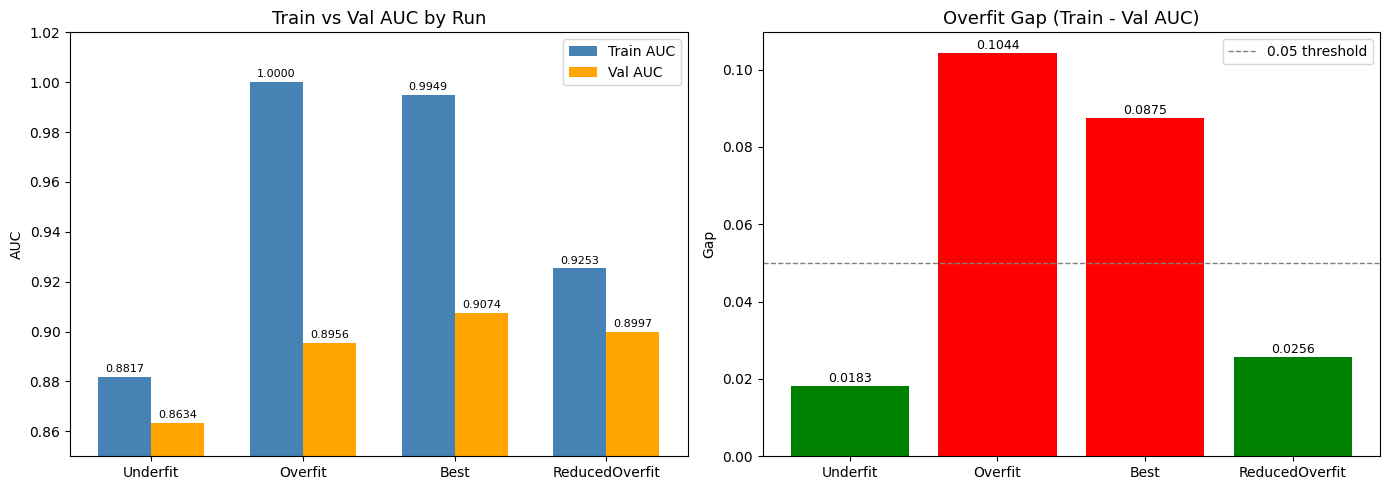

🏃 View run XGBoost_Final_Pipeline at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/b05de237a89d4196914e270844f2b69a
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [25]:
import matplotlib.pyplot as plt
import numpy as np

results = {
    'Underfit':       {'train': 0.8817, 'val': 0.8634},
    'Overfit':        {'train': 1.0000, 'val': 0.8956},
    'Best':           {'train': 0.9949, 'val': 0.9074},
    'ReducedOverfit': {'train': 0.9253, 'val': 0.8997},
}
labels = list(results.keys())
train_aucs = [results[k]['train'] for k in labels]
val_aucs   = [results[k]['val']   for k in labels]
gaps       = [t - v for t, v in zip(train_aucs, val_aucs)]

x = np.arange(len(labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w/2, train_aucs, w, color='steelblue', label='Train AUC')
axes[0].bar(x + w/2, val_aucs,   w, color='orange',    label='Val AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.85, 1.02)
axes[0].set_title('Train vs Val AUC by Run', fontsize=13)
axes[0].set_ylabel('AUC')
axes[0].legend()
for i in range(len(labels)):
    axes[0].text(x[i] - w/2, train_aucs[i] + 0.002, f'{train_aucs[i]:.4f}', ha='center', fontsize=8)
    axes[0].text(x[i] + w/2, val_aucs[i]   + 0.002, f'{val_aucs[i]:.4f}',   ha='center', fontsize=8)

gap_colors = ['green' if g < 0.03 else 'orange' if g < 0.07 else 'red' for g in gaps]
axes[1].bar(labels, gaps, color=gap_colors)
axes[1].axhline(y=0.05, color='gray', linestyle='--', linewidth=1, label='0.05 threshold')
axes[1].set_title('Overfit Gap (Train - Val AUC)', fontsize=13)
axes[1].set_ylabel('Gap')
axes[1].legend()
for i, g in enumerate(gaps):
    axes[1].text(i, g + 0.001, f'{g:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('xgb_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name="XGBoost_Final_Pipeline", nested=True):
    mlflow.log_artifact('xgb_model_comparison.png')

# 💾 Pipeline & Model Registry

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import mlflow.sklearn

best_params = {
    'n_estimators': 500, 'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.7, 'colsample_bytree': 0.7,
    'reg_alpha': 1.0, 'reg_lambda': 5.0,
    'min_child_weight': 20,
    'scale_pos_weight': 30,
    'tree_method': 'hist', 'random_state': 42
}

best_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-999)),
    ('classifier', XGBClassifier(**best_params))
])

best_pipeline.fit(X_train, y_train)

with mlflow.start_run(run_name="XGBoost_Final_Pipeline", nested=True):
    train_auc = roc_auc_score(y_train, best_pipeline.predict_proba(X_train)[:,1])
    val_auc = roc_auc_score(y_val, best_pipeline.predict_proba(X_val)[:,1])
    
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("overfit_gap", train_auc - val_auc)
    mlflow.log_param("selected_features_count", len(selected_features))
    
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="xgboost_pipeline",
        registered_model_name="XGBoost_Fraud_Pipeline",
        input_example=X_val.iloc[:5]
    )
    
    print(f"✅ Pipeline saved to Model Registry!")
    print(f"Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")

2026/05/07 15:19:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 15:19:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can 

✅ Pipeline saved to Model Registry!
Train AUC: 0.9723 | Val AUC: 0.9162
🏃 View run XGBoost_Final_Pipeline at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0/runs/6e9ea7c4e47b4174ac5a1950596d52f0
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML-assignment2-IEEE-Fraud-Detection.mlflow/#/experiments/0


In [27]:
import json

with open('selected_features_xgboost.json', 'w') as f:
    json.dump(selected_features, f)

mlflow.log_artifact('selected_features_xgboost.json')
print("✅ Feature list saved!")

✅ Feature list saved!


In [28]:
model.save_model("xgb_fraud_model.json")

In [29]:
import os
if os.path.exists('/kaggle/working/xgb_fraud_model.json'):
    print(f"✅ CONFIRMED: File exists. Size: {os.path.getsize('/kaggle/working/xgb_fraud_model.json')/1024**2:.2f} MB")
else:
    print("❌ ERROR: File was NOT saved.")

✅ CONFIRMED: File exists. Size: 13.73 MB
